# 08 — Cross-method IoU: spatial agreement between XAI methods

Loads the saved heatmaps from all five models (07a–07e) and measures how much the four methods spatially agree, using Intersection-over-Union of their most-important regions.

Two outputs:
1. **Full 4×4 agreement matrix per model** — which methods point at the same regions.
2. **LIME-vs-others summary** — directly tests whether LIME behaves consistently across architectures (the 'most architecture-agnostic' claim).

IoU is reported at **three thresholds (top 10%, 20%, 30%)** so the conclusion does not depend on an arbitrary cutoff. LIME is already a binary mask; the other three continuous heatmaps are thresholded to their top-k% most-important pixels.

**Attach:** the committed outputs of 07a, 07b, 07c, 07d, 07e (each holds `<model>_<method>_heatmaps.npy`). No GPU.

In [1]:
import os, re, numpy as np, itertools, json
import matplotlib.pyplot as plt

MODELS = ["vanilla_cnn","inception_v3","convnext_tiny","deit_base","swin_base"]
PRETTY = {"vanilla_cnn":"Vanilla CNN","inception_v3":"Inception V3","convnext_tiny":"ConvNeXt-Tiny",
          "deit_base":"DeiT-Base","swin_base":"Swin-Base"}
METHODS = ["gradcam","saliency","shap","lime"]

# locate every saved heatmap file
hm_paths = {}
for r,_,fs in os.walk("/kaggle/input"):
    for x in fs:
        m = re.match(r"(.+?)_(gradcam|saliency|shap|lime)_heatmaps\.npy$", x)
        if m: hm_paths[(m.group(1), m.group(2))] = os.path.join(r,x)
print("Found heatmap arrays:")
for k in sorted(hm_paths): print("  ", k[0], k[1])

Found heatmap arrays:
   convnext_tiny gradcam
   convnext_tiny lime
   convnext_tiny saliency
   convnext_tiny shap
   deit_base gradcam
   deit_base lime
   deit_base saliency
   deit_base shap
   inception_v3 gradcam
   inception_v3 lime
   inception_v3 saliency
   inception_v3 shap
   swin_base gradcam
   swin_base lime
   swin_base saliency
   swin_base shap
   vanilla_cnn gradcam
   vanilla_cnn lime
   vanilla_cnn saliency
   vanilla_cnn shap


In [2]:
# load all heatmaps into memory: heatmaps[model][method] = (30,H,W)
heatmaps = {}
for model in MODELS:
    heatmaps[model] = {}
    for method in METHODS:
        p = hm_paths.get((model,method))
        if p is None:
            print(f"MISSING: {model} {method}"); continue
        heatmaps[model][method] = np.load(p)
print("Loaded. Models with all 4 methods:",
      [m for m in MODELS if len(heatmaps.get(m,{}))==4])

Loaded. Models with all 4 methods: ['vanilla_cnn', 'inception_v3', 'convnext_tiny', 'deit_base', 'swin_base']


In [3]:
def binarise(hmap, topk):
    """Top-k fraction of pixels -> boolean mask. LIME (already ~binary) handled the same way."""
    h = np.asarray(hmap, dtype=float)
    if h.max() <= 0: return np.zeros_like(h, dtype=bool)
    thresh = np.quantile(h, 1.0 - topk)
    return h >= thresh

def iou(a, b):
    inter = np.logical_and(a,b).sum(); union = np.logical_or(a,b).sum()
    return inter/union if union>0 else 0.0

def pair_iou(model, m1, m2, topk):
    """Mean IoU across the 30 images for two methods on one model."""
    H1, H2 = heatmaps[model][m1], heatmaps[model][m2]
    vals=[]
    for i in range(len(H1)):
        vals.append(iou(binarise(H1[i],topk), binarise(H2[i],topk)))
    return np.mean(vals)

THRESHOLDS = [0.10, 0.20, 0.30]
print("IoU helpers ready. Thresholds:", THRESHOLDS)

IoU helpers ready. Thresholds: [0.1, 0.2, 0.3]


## 1. Full 4×4 method-agreement matrix per model (at top-20%)

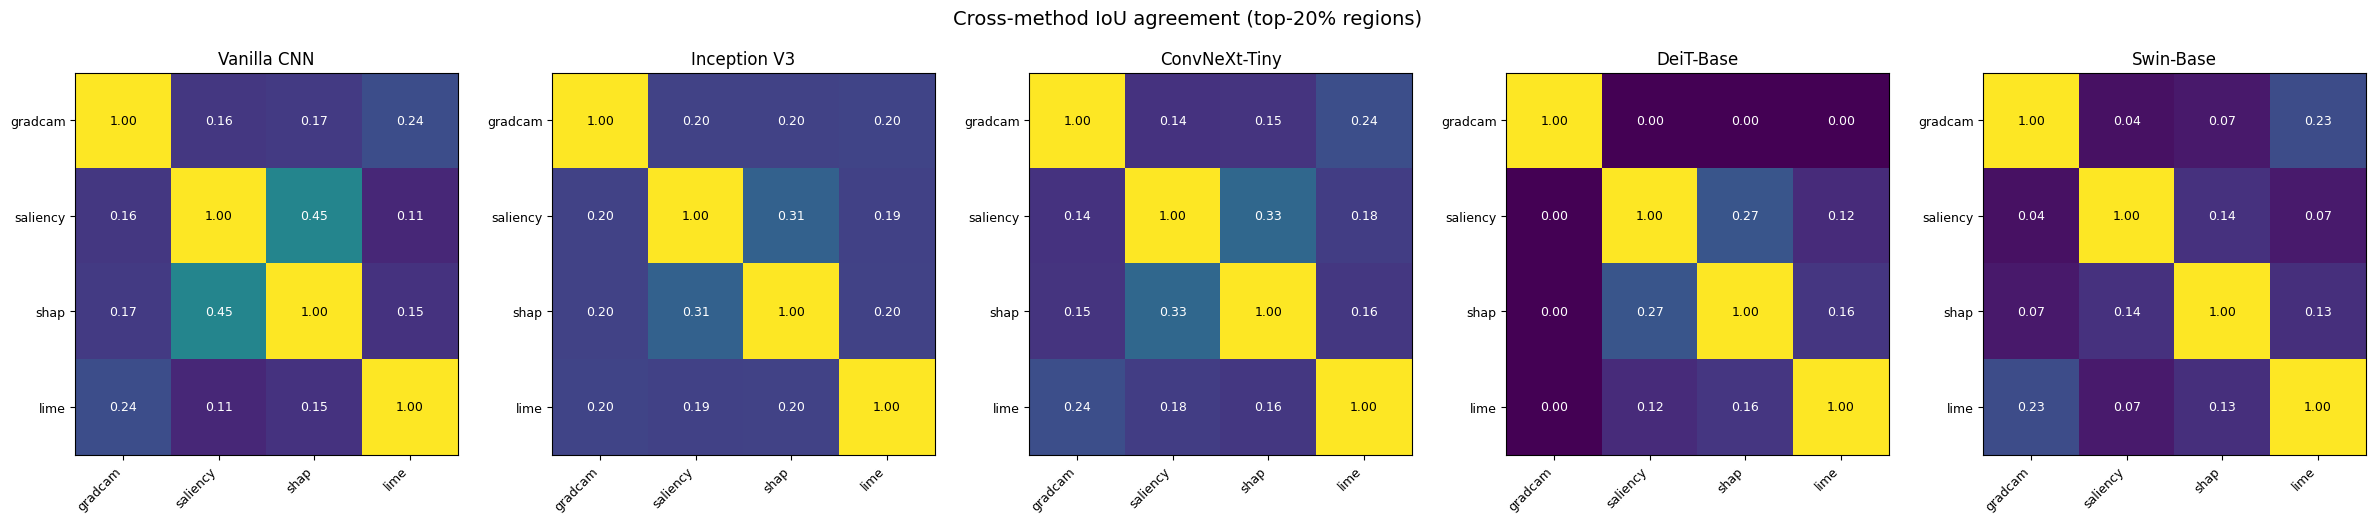

Saved fig_iou_matrices.png


In [4]:
fig, axes = plt.subplots(1, 5, figsize=(24, 4.8))
topk_main = 0.20
matrices = {}
for ax, model in zip(axes, MODELS):
    M = np.zeros((4,4))
    for a in range(4):
        for b in range(4):
            M[a,b] = 1.0 if a==b else pair_iou(model, METHODS[a], METHODS[b], topk_main)
    matrices[model] = M
    im = ax.imshow(M, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(METHODS, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(METHODS, fontsize=9)
    ax.set_title(PRETTY[model], fontsize=12)
    for a in range(4):
        for b in range(4):
            ax.text(b,a,f"{M[a,b]:.2f}",ha="center",va="center",
                    color="white" if M[a,b]<0.6 else "black", fontsize=9)
plt.suptitle("Cross-method IoU agreement (top-20% regions)", fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_iou_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved fig_iou_matrices.png")

## 2. LIME-vs-others: is LIME consistent across architectures?

For each model, the mean IoU between LIME and the other three methods. If LIME is genuinely architecture-agnostic, its agreement with the gradient methods should not swing wildly between CNNs and transformers the way the gradient methods swing among themselves.

In [5]:
rows=[]
for model in MODELS:
    for topk in THRESHOLDS:
        lime_vs = np.mean([pair_iou(model,"lime",o,topk) for o in ["gradcam","saliency","shap"]])
        # also the mean agreement AMONG the gradient methods (for contrast)
        grad_pairs=[("gradcam","saliency"),("gradcam","shap"),("saliency","shap")]
        grad_among=np.mean([pair_iou(model,a,b,topk) for a,b in grad_pairs])
        rows.append(dict(model=PRETTY[model], topk=f"top-{int(topk*100)}%",
                         lime_vs_others=round(lime_vs,3), gradient_among=round(grad_among,3)))
import pandas as pd
df=pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv("/kaggle/working/iou_lime_summary.csv", index=False)
print("\nSaved iou_lime_summary.csv")

        model    topk  lime_vs_others  gradient_among
  Vanilla CNN top-10%           0.098           0.218
  Vanilla CNN top-20%           0.166           0.262
  Vanilla CNN top-30%           0.260           0.324
 Inception V3 top-10%           0.084           0.136
 Inception V3 top-20%           0.199           0.236
 Inception V3 top-30%           0.300           0.323
ConvNeXt-Tiny top-10%           0.112           0.149
ConvNeXt-Tiny top-20%           0.195           0.209
ConvNeXt-Tiny top-30%           0.281           0.269
    DeiT-Base top-10%           0.051           0.060
    DeiT-Base top-20%           0.094           0.088
    DeiT-Base top-30%           0.154           0.113
    Swin-Base top-10%           0.080           0.036
    Swin-Base top-20%           0.146           0.085
    Swin-Base top-30%           0.211           0.142

Saved iou_lime_summary.csv


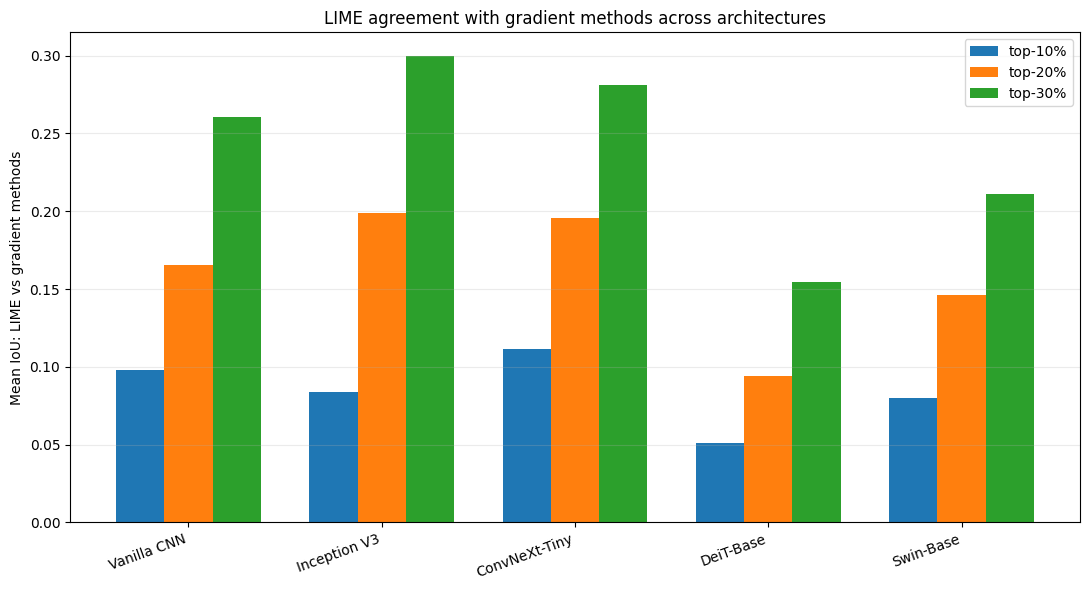

Saved fig_iou_lime_across_models.png


In [6]:
# Visualise LIME-vs-others across models at the three thresholds
fig, ax = plt.subplots(figsize=(11,6))
x=np.arange(len(MODELS)); width=0.25
for j,topk in enumerate(THRESHOLDS):
    vals=[np.mean([pair_iou(m,"lime",o,topk) for o in ["gradcam","saliency","shap"]]) for m in MODELS]
    ax.bar(x+(j-1)*width, vals, width, label=f"top-{int(topk*100)}%")
ax.set_xticks(x); ax.set_xticklabels([PRETTY[m] for m in MODELS], rotation=20, ha="right")
ax.set_ylabel("Mean IoU: LIME vs gradient methods")
ax.set_title("LIME agreement with gradient methods across architectures")
     
ax.legend(); ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_iou_lime_across_models.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved fig_iou_lime_across_models.png")

## 3. Robustness check: does the ranking hold across thresholds?

In [7]:
print("Mean cross-method IoU per model, at each threshold:")
print("(overall agreement among all 4 methods — higher = methods concur more)")
for model in MODELS:
    line=f"  {PRETTY[model]:<15}"
    for topk in THRESHOLDS:
        pairs=list(itertools.combinations(METHODS,2))
        mean_iou=np.mean([pair_iou(model,a,b,topk) for a,b in pairs])
        line+=f" top{int(topk*100)}={mean_iou:.3f}"
    print(line)
print("\nInterpretation: report LIME-vs-others alongside gradient-among-gradient.")
print("If LIME stays moderate & stable while gradient agreement swings by architecture,")
print("that supports LIME as the most architecture-agnostic method.")

Mean cross-method IoU per model, at each threshold:
(overall agreement among all 4 methods — higher = methods concur more)
  Vanilla CNN     top10=0.158 top20=0.214 top30=0.292
  Inception V3    top10=0.110 top20=0.217 top30=0.311
  ConvNeXt-Tiny   top10=0.130 top20=0.202 top30=0.275
  DeiT-Base       top10=0.055 top20=0.091 top30=0.134
  Swin-Base       top10=0.058 top20=0.116 top30=0.177

Interpretation: report LIME-vs-others alongside gradient-among-gradient.
If LIME stays moderate & stable while gradient agreement swings by architecture,
that supports LIME as the most architecture-agnostic method.
